# EDA operativo del mes disponible

Notebook de documentación para el sample de diciembre 2025 del dataset BTS Reporting Carrier On-Time Performance.

Objetivo: validar la viabilidad de ingeniería de características para un modelo predictivo de retrasos, sabiendo que este archivo contiene solo un mes y que el entrenamiento real deberá escalar a 2-3 años de datos sobre ATL, ORD, JFK y MIA.

## 1. Carga y validación de datos

Cargamos el archivo disponible, revisamos esquema, columnas clave y rango temporal. Como este sample cubre solo un mes, el objetivo no es inferir estacionalidad de largo plazo sino validar señales operativas y estabilidad de features para una futura ampliación a 2 o 3 años.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

DATA_PATH = Path('/Users/mateopappalardo/Downloads/tesis_local/DEC_2025_BTS.csv')
df_raw = pd.read_csv(DATA_PATH)

print('Filas:', len(df_raw))
print('Columnas:', len(df_raw.columns))
print('Rango inicial de FL_DATE:', df_raw['FL_DATE'].head(1).iloc[0], '->', df_raw['FL_DATE'].tail(1).iloc[0])
print('\nEsquema resumido:')
print(df_raw.dtypes)
print('\nPrimeras filas:')
display(df_raw.head(5))

Filas: 582304
Columnas: 42
Rango inicial de FL_DATE: 12/1/2025 12:00:00 AM -> 12/31/2025 12:00:00 AM

Esquema resumido:
YEAR                     int64
QUARTER                  int64
MONTH                    int64
DAY_OF_MONTH             int64
DAY_OF_WEEK              int64
FL_DATE                 object
OP_CARRIER              object
TAIL_NUM                object
OP_CARRIER_FL_NUM        int64
ORIGIN_AIRPORT_ID        int64
ORIGIN                  object
ORIGIN_WAC               int64
DEST_AIRPORT_ID          int64
DEST                    object
DEST_WAC                 int64
CRS_DEP_TIME             int64
DEP_TIME               float64
DEP_DELAY              float64
DEP_DEL15              float64
DEP_DELAY_GROUP        float64
TAXI_OUT               float64
WHEELS_OFF             float64
WHEELS_ON              float64
TAXI_IN                float64
CRS_ARR_TIME             int64
ARR_TIME               float64
ARR_DELAY              float64
ARR_DEL15              float64
ARR_DELAY_GR

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_WAC,DEST_AIRPORT_ID,DEST,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DEL15,ARR_DELAY_GROUP,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2025,4,12,1,1,12/1/2025 12:00:00 AM,AA,N101NN,1,12478,JFK,22,12892,LAX,91,700,717.0,17.0,1.0,1.0,19.0,736.0,1014.0,16.0,1035,1030.0,-5.0,0.0,-1.0,0.0,NaN,0.0,395.0,373.0,338.0,1.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025,4,12,1,1,12/1/2025 12:00:00 AM,AA,N101NN,300,12478,JFK,22,12892,LAX,91,2100,2054.0,-6.0,0.0,-1.0,12.0,2106.0,2342.0,10.0,28,2352.0,-36.0,0.0,-2.0,0.0,NaN,0.0,388.0,358.0,336.0,1.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025,4,12,1,1,12/1/2025 12:00:00 AM,AA,N101NN,32,12892,LAX,91,12478,JFK,22,1135,1133.0,-2.0,0.0,-1.0,18.0,1151.0,1937.0,15.0,2000,1952.0,-8.0,0.0,-1.0,0.0,NaN,0.0,325.0,319.0,286.0,1.0,2475.0,NaN,NaN,NaN,NaN,NaN
3,2025,4,12,1,1,12/1/2025 12:00:00 AM,AA,N102NN,118,12892,LAX,91,12478,JFK,22,605,1210.0,365.0,1.0,12.0,14.0,1224.0,2014.0,8.0,1430,2022.0,352.0,1.0,12.0,0.0,NaN,0.0,325.0,312.0,290.0,1.0,2475.0,352.0,0.0,0.0,0.0,0.0
4,2025,4,12,1,1,12/1/2025 12:00:00 AM,AA,N102UW,2301,10792,BUF,22,11057,CLT,36,1913,1934.0,21.0,1.0,1.0,10.0,1944.0,2120.0,8.0,2115,2128.0,13.0,0.0,0.0,0.0,NaN,0.0,122.0,114.0,96.0,1.0,546.0,NaN,NaN,NaN,NaN,NaN


## 2. Normalización y preparación inicial

Esta etapa deja el dataset listo para análisis reproducible: nombres consistentes, fechas parseadas y variables operativas tipadas de forma estable. También prepara las columnas que luego se cruzarán con una API meteorológica.

In [2]:
df = df_raw.copy()
df.columns = [c.strip().upper() for c in df.columns]

DATE_FORMAT = '%m/%d/%Y %I:%M:%S %p'
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format=DATE_FORMAT, errors='coerce')

for col in ['DEP_DELAY', 'CANCELLED', 'CARRIER_DELAY', 'WEATHER_DELAY', 'LATE_AIRCRAFT_DELAY', 'ARR_DELAY', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'DEP_TIME', 'ARR_TIME']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['ORIGIN', 'DEST', 'TAIL_NUM', 'OP_CARRIER']:
    if col in df.columns:
        df[col] = df[col].astype('string').str.strip().str.upper()

print('Nulos por columna crítica:')
for col in ['ORIGIN', 'DEST', 'FL_DATE', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'TAIL_NUM']:
    print(f'{col}: {int(df[col].isna().sum())}')

print('\nDuplicados exactos:', int(df.duplicated().sum()))
print('Rango temporal limpio:', df['FL_DATE'].min(), '->', df['FL_DATE'].max())

# Mantener una versión lista para el resto del notebook.
df = df.drop_duplicates().reset_index(drop=True)
print('Filas tras deduplicar:', len(df))

Nulos por columna crítica:
ORIGIN: 0
DEST: 0
FL_DATE: 0
CRS_DEP_TIME: 0
CRS_ARR_TIME: 0
TAIL_NUM: 853

Duplicados exactos: 0
Rango temporal limpio: 2025-12-01 00:00:00 -> 2025-12-31 00:00:00
Filas tras deduplicar: 582304


## 3. Análisis exploratorio del mes disponible

En esta sección medimos el desbalance del target, los retrasos explicados por variables causales y el nivel de soporte de la señal por matrícula. El foco no es decorar con gráficos, sino validar si hay masa crítica para ingeniería de features.

In [7]:
target = np.select(
    [df['CANCELLED'].eq(1), df['DEP_DELAY'].lt(15), df['DEP_DELAY'].lt(45), df['DEP_DELAY'].lt(90)],
    ['Rojo', 'Verde', 'Amarillo', 'Naranja'],
    default='Rojo',
)

# Flights with missing DEP_DELAY and not cancelled remain unassigned; they should be reviewed before modeling.
df['TARGET_4C'] = pd.Series(target, index=df.index)

target_dist = df['TARGET_4C'].value_counts(dropna=False).to_frame('count')
target_dist['pct'] = (target_dist['count'] / len(df) * 100).round(2)
print('Distribución del target de 4 escalones:')
display(target_dist)

print('\nTasa de retraso >= 15 min entre vuelos no cancelados:')
rate_ge15 = (df.loc[df['CANCELLED'] != 1, 'DEP_DELAY'] >= 15).mean()
print(round(rate_ge15 * 100, 2), '%')

print('\nComposición del escalón Rojo:')
red_cancelled = int(df['CANCELLED'].eq(1).sum())
red_delay = int(((df['CANCELLED'] != 1) & df['DEP_DELAY'].ge(90)).sum())
print('Cancelados:', red_cancelled)
print('Retrasos >= 90 min:', red_delay)
print('Total Rojo:', red_cancelled + red_delay)

Distribución del target de 4 escalones:


,count,pct
TARGET_4C,,
Verde,419295,72.01
Amarillo,78740,13.52
Rojo,44809,7.70
Naranja,39460,6.78



Tasa de retraso >= 15 min entre vuelos no cancelados:
26.86 %

Composición del escalón Rojo:
Cancelados: 9001
Retrasos >= 90 min: 35808
Total Rojo: 44809


In [8]:
positive_delays = df.loc[df['DEP_DELAY'] > 0, ['DEP_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 'LATE_AIRCRAFT_DELAY']].fillna(0).copy()
positive_delay_total = positive_delays['DEP_DELAY'].sum()
explained = positive_delays[['CARRIER_DELAY', 'WEATHER_DELAY', 'LATE_AIRCRAFT_DELAY']].sum()
explained_pct = (explained / positive_delay_total * 100).round(2)

print('Minutos totales de retraso positivo:', round(positive_delay_total, 2))
print('\nMinutos explicados por cada componente:')
display(explained.to_frame('minutes'))
print('\nParticipación porcentual sobre el total de retrasos positivos:')
display(explained_pct.to_frame('pct_of_positive_delay'))
print('\nShare de LateAircraftDelay:', round(explained_pct['LATE_AIRCRAFT_DELAY'], 2), '%')

Minutos totales de retraso positivo: 12175955.0

Minutos explicados por cada componente:


,minutes
CARRIER_DELAY,3760709.0
WEATHER_DELAY,729797.0
LATE_AIRCRAFT_DELAY,4716435.0



Participación porcentual sobre el total de retrasos positivos:


,pct_of_positive_delay
CARRIER_DELAY,30.89
WEATHER_DELAY,5.99
LATE_AIRCRAFT_DELAY,38.74



Share de LateAircraftDelay: 38.74 %


## 4. Análisis temporal intra-mes

Este bloque mira el comportamiento dentro del mes disponible. Dado que el periodo es corto, cualquier lectura de estacionalidad debe tomarse como señal local y no como patrón robusto anual.

In [9]:
def hhmm_to_minutes(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors='coerce')
    hours = np.floor(values / 100)
    minutes = values % 100
    invalid = (values < 0) | (hours > 23) | (minutes >= 60)
    out = hours * 60 + minutes
    out = out.astype('float64')
    out[invalid] = np.nan
    return out

for col in ['CRS_DEP_TIME', 'CRS_ARR_TIME', 'DEP_TIME', 'ARR_TIME']:
    df[f'{col}_MIN'] = hhmm_to_minutes(df[col])

print('Ejemplos de conversión HHMM -> minutos:')
display(df[['CRS_DEP_TIME', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME', 'CRS_ARR_TIME_MIN']].head(10))

# Si el mes tuviera más de una fecha, esto permite estudiar intrames de forma estable.
df['DAY'] = df['FL_DATE'].dt.day
df['DOW'] = df['FL_DATE'].dt.day_name()
df['HOUR_DEP'] = (df['CRS_DEP_TIME_MIN'] // 60).astype('Int64')

by_day = df.groupby('DAY').agg(
    flights=('FL_DATE', 'size'),
    delay_ge15_rate=('DEP_DELAY', lambda s: (s >= 15).mean()),
    avg_dep_delay=('DEP_DELAY', 'mean'),
    cancel_rate=('CANCELLED', 'mean'),
)
print('\nResumen por día del mes:')
display(by_day)

by_dow = df.groupby('DOW').agg(
    flights=('FL_DATE', 'size'),
    delay_ge15_rate=('DEP_DELAY', lambda s: (s >= 15).mean()),
    avg_dep_delay=('DEP_DELAY', 'mean'),
)
print('\nResumen por día de la semana:')
display(by_dow.sort_values('flights', ascending=False))

by_hour = df.groupby('HOUR_DEP').agg(
    flights=('FL_DATE', 'size'),
    delay_ge15_rate=('DEP_DELAY', lambda s: (s >= 15).mean()),
    avg_dep_delay=('DEP_DELAY', 'mean'),
)
print('\nResumen por hora programada de salida:')
display(by_hour.head(24))

Ejemplos de conversión HHMM -> minutos:


,CRS_DEP_TIME,CRS_DEP_TIME_MIN,CRS_ARR_TIME,CRS_ARR_TIME_MIN
0,700,420.0,1035,635.0
1,2100,1260.0,28,28.0
2,1135,695.0,2000,1200.0
3,605,365.0,1430,870.0
4,1913,1153.0,2115,1275.0
5,1643,1003.0,1828,1108.0
6,1120,680.0,1214,734.0
7,1259,779.0,1548,948.0
8,821,501.0,1054,654.0
9,705,425.0,736,456.0



Resumen por día del mes:


,flights,delay_ge15_rate,avg_dep_delay,cancel_rate
DAY,,,,
1,21089,0.340035,25.997285,0.022571
2,17989,0.320529,22.016198,0.008505
3,17751,0.233959,13.821967,0.003098
4,19442,0.240716,13.767844,0.001389
5,19238,0.259746,17.192665,0.015386
6,16339,0.171798,9.596214,0.008018
7,19972,0.370268,39.538717,0.035550
8,19236,0.240227,16.342119,0.018247
9,17408,0.155676,7.878290,0.002872



Resumen por día de la semana:


,flights,delay_ge15_rate,avg_dep_delay
DOW,,,
Monday,99727,0.283073,19.515371
Tuesday,92642,0.233760,14.327817
Wednesday,85164,0.198781,10.846817
Sunday,80006,0.347249,31.413199
Friday,79443,0.293858,21.861484
Thursday,74287,0.223606,12.868300
Saturday,71035,0.276751,18.152407



Resumen por hora programada de salida:


,flights,delay_ge15_rate,avg_dep_delay
HOUR_DEP,,,
0,1130,0.215044,13.198741
1,361,0.337950,25.430199
2,124,0.282258,14.000000
3,81,0.209877,15.975000
4,25,0.200000,18.375000
5,17078,0.094976,8.610116
6,40227,0.105824,8.023732
7,42539,0.130116,8.991180
8,40489,0.162908,10.707087


## 5. Análisis por aeropuerto

Filtramos los aeropuertos de interés del MVP y medimos su volumen operativo y tasa de retraso. Esto sirve para decidir si el piloto puede concentrarse en unos pocos hubs sin perder diversidad de comportamiento.

In [10]:
hubs = ['ATL', 'ORD', 'JFK', 'MIA']
hub_df = df[df['ORIGIN'].isin(hubs)].copy()

hub_summary = hub_df.groupby('ORIGIN').agg(
    flights=('FL_DATE', 'size'),
    delay_ge15_rate=('DEP_DELAY', lambda s: (s >= 15).mean()),
    avg_dep_delay=('DEP_DELAY', 'mean'),
    cancel_rate=('CANCELLED', 'mean'),
    unique_tails=('TAIL_NUM', 'nunique'),
).sort_values('flights', ascending=False)

print('Filas resultantes:', len(hub_df))
print('Participación sobre el total:', round(len(hub_df) / len(df) * 100, 2), '%')
print('\nMétricas por hub:')
display(hub_summary)

# Señal útil para comparar comportamiento operativo entre hubs.
print('\nConclusión rápida:')
print('ORD suele concentrar la mayor presión operativa; MIA suele ser más benigno en invierno; JFK y ATL tienden a quedar en el medio con variación relevante por cancelaciones y clima.')

Filas resultantes: 72509
Participación sobre el total: 12.45 %

Métricas por hub:


,flights,delay_ge15_rate,avg_dep_delay,cancel_rate,unique_tails
ORIGIN,,,,,
ORD,27790,0.345448,31.557963,0.025261,3119
ATL,25764,0.269873,17.794340,0.023832,2932
MIA,10099,0.253292,15.147748,0.011486,2332
JFK,8856,0.290425,22.855200,0.040199,1685



Conclusión rápida:
ORD suele concentrar la mayor presión operativa; MIA suele ser más benigno en invierno; JFK y ATL tienden a quedar en el medio con variación relevante por cancelaciones y clima.


## 6. Comparación entre aeropuertos y patrones operativos

La comparación busca diferencias operativas observables, no causalidad fuerte. Con un solo mes, estas diferencias sirven para priorizar hipótesis y features, pero no para generalizar de forma definitiva.

In [11]:
comparison = hub_df.groupby('ORIGIN').agg(
    flights=('FL_DATE', 'size'),
    avg_dep_delay=('DEP_DELAY', 'mean'),
    median_dep_delay=('DEP_DELAY', 'median'),
    p90_dep_delay=('DEP_DELAY', lambda s: s.quantile(0.90)),
    delay_ge15_rate=('DEP_DELAY', lambda s: (s >= 15).mean()),
    late_aircraft_share=('LATE_AIRCRAFT_DELAY', lambda s: s.fillna(0).sum()),
    weather_share=('WEATHER_DELAY', lambda s: s.fillna(0).sum()),
).sort_values('delay_ge15_rate', ascending=False)

print('Comparación resumida entre hubs:')
display(comparison)

# Normalización de contribuciones sobre retrasos positivos por hub.
for hub in hubs:
    sub = hub_df[hub_df['ORIGIN'] == hub].copy()
    positive = sub.loc[sub['DEP_DELAY'] > 0, ['DEP_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'CARRIER_DELAY']].fillna(0)
    total_pos = positive['DEP_DELAY'].sum()
    contrib = (positive[['LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'CARRIER_DELAY']].sum() / total_pos * 100).round(2)
    print(f'\n{hub}:')
    print(contrib.to_string())

Comparación resumida entre hubs:


,flights,avg_dep_delay,median_dep_delay,p90_dep_delay,delay_ge15_rate,late_aircraft_share,weather_share
ORIGIN,,,,,,,
ORD,27790,31.557963,3.0,99.3,0.345448,383628.0,132033.0
JFK,8856,22.855200,0.0,76.0,0.290425,82233.0,15899.0
ATL,25764,17.794340,0.0,57.0,0.269873,150730.0,39774.0
MIA,10099,15.147748,-1.0,51.0,0.253292,67510.0,3326.0



ATL:
LATE_AIRCRAFT_DELAY    29.66
WEATHER_DELAY           7.83
CARRIER_DELAY          39.01

ORD:
LATE_AIRCRAFT_DELAY    42.38
WEATHER_DELAY          14.59
CARRIER_DELAY          24.84

JFK:
LATE_AIRCRAFT_DELAY    38.28
WEATHER_DELAY           7.40
CARRIER_DELAY          30.36

MIA:
LATE_AIRCRAFT_DELAY    37.63
WEATHER_DELAY           1.85
CARRIER_DELAY          33.79


## 7. Control de calidad y sesgos por ventana temporal corta

Este mes sirve para validar el pipeline y la señal operativa, pero no para cerrar conclusiones globales sobre comportamiento anual. Las features estacionales, semanales y por aeropuerto deberán volver a evaluarse cuando el histórico cubra 24 a 36 meses.

In [12]:
quality = {
    'ORIGIN_nulls': int(df['ORIGIN'].isna().sum()),
    'DEST_nulls': int(df['DEST'].isna().sum()),
    'FL_DATE_nulls': int(df['FL_DATE'].isna().sum()),
    'CRS_DEP_TIME_nulls': int(df['CRS_DEP_TIME'].isna().sum()),
    'CRS_ARR_TIME_nulls': int(df['CRS_ARR_TIME'].isna().sum()),
}

print('Nulos críticos:')
for k, v in quality.items():
    print(k, v)

print('\nValidación de formato HHMM en tiempos CRS:')
for col in ['CRS_DEP_TIME', 'CRS_ARR_TIME']:
    bad = df[col].notna() & (((df[col] % 100) >= 60) | (np.floor(df[col] / 100) > 23) | (df[col] < 0))
    print(col, 'valores inválidos:', int(bad.sum()))

print('\nTipos finales de las columnas críticas:')
for col in ['ORIGIN', 'DEST', 'FL_DATE', 'CRS_DEP_TIME', 'CRS_ARR_TIME']:
    print(col, df[col].dtype)

print('\nRecomendación de limpieza para el pipeline:')
print('- Parsear FL_DATE con formato explícito y convertir a datetime.')
print('- Mantener ORIGIN y DEST como strings en mayúsculas, sin espacios.')
print('- Convertir CRS_DEP_TIME y CRS_ARR_TIME a minutos desde medianoche para cruzarlas con clima.')
print('- No usar DEP_TIME, ARR_TIME, ARR_DELAY ni variables de demora como features de entrenamiento antes del despegue.')

Nulos críticos:
ORIGIN_nulls 0
DEST_nulls 0
FL_DATE_nulls 0
CRS_DEP_TIME_nulls 0
CRS_ARR_TIME_nulls 0

Validación de formato HHMM en tiempos CRS:
CRS_DEP_TIME valores inválidos: 0
CRS_ARR_TIME valores inválidos: 0

Tipos finales de las columnas críticas:
ORIGIN string
DEST string
FL_DATE datetime64[ns]
CRS_DEP_TIME int64
CRS_ARR_TIME int64

Recomendación de limpieza para el pipeline:
- Parsear FL_DATE con formato explícito y convertir a datetime.
- Mantener ORIGIN y DEST como strings en mayúsculas, sin espacios.
- Convertir CRS_DEP_TIME y CRS_ARR_TIME a minutos desde medianoche para cruzarlas con clima.
- No usar DEP_TIME, ARR_TIME, ARR_DELAY ni variables de demora como features de entrenamiento antes del despegue.


## 8. Especificación final de features

La siguiente propuesta está pensada para un modelo entrenado con 2 o 3 años de datos de ATL, ORD, JFK y MIA. La prioridad es usar solo variables disponibles antes del despegue y dejar fuera cualquier señal que aparezca después del evento o que sea una derivación directa del retraso.

### Features candidatas permitidas antes del despegue

- Temporales: mes, día de la semana, día del mes, franja horaria CRS, fin de semana, feriado si se incorpora una tabla externa.
- Aeropuerto/origen: ORIGIN, DEST, ruta O-D, región, distancia, banda de distancia.
- Operativas programadas: CRS_DEP_TIME, CRS_ARR_TIME, CRS_ELAPSED_TIME, DISTANCE, carrier, número de vuelo normalizado.
- Históricas agregadas por aeropuerto y carrier: tasa de retraso de 7, 30, 60 y 90 días, volumen de vuelos, cancelación reciente, percentiles de demora histórica, densidad de conexiones, tasa de llegada tardía del carrier y del aeropuerto.
- Cascada logística: turnaround previo de la aeronave, promedio móvil de demora por Tail_Num, secuencia de vuelos del mismo tail dentro del día, siempre usando solo vuelos anteriores.
- Clima exógeno: visibilidad, viento, precipitación, nieve, tormenta, temperatura, techo de nubes y condición METAR/SPECI alineada al CRS_DEP_TIME.

### Features a excluir por leakage

- DEP_TIME, ARR_TIME, WHEELS_OFF, WHEELS_ON, TAXI_OUT, TAXI_IN.
- DEP_DELAY, ARR_DELAY, DEP_DEL15, ARR_DEL15 y cualquier bucket derivado del target.
- CARRIER_DELAY, WEATHER_DELAY, NAS_DELAY, SECURITY_DELAY, LATE_AIRCRAFT_DELAY.
- ACTUAL_ELAPSED_TIME y cualquier variable calculada con datos post-salida o post-arribo.

### Regla práctica para el modelo

Para cada vuelo, construir features con ventanas retrospectivas cerradas en el instante CRS_DEP_TIME. Si una variable depende de un evento posterior al pushback, no debe entrar al entrenamiento.

## 9. Notas para escalar a 2–3 años de datos

Cuando tengamos más histórico, este mismo análisis debe repetirse con ventanas temporales largas para validar estabilidad, estacionalidad y generalización. En ese punto sí podremos estimar diferencias robustas entre invierno, verano, holiday peaks y patrones de congestión por aeropuerto.

### Qué agregar cuando exista el histórico completo

- Validación temporal por train/validation/test en orden cronológico, no aleatoria.
- Métricas estacionales por mes, trimestre y temporada operativa.
- Features agregadas con lookback fijo y decay temporal para aeropuerto, carrier, ruta y tail number.
- Controles de drift por aeropuerto y por carrier.
- Ajuste de desbalanceo por clase y calibración de probabilidades para el escalón operativo final.

Con 2-3 años de datos, la señal de cascada logística y clima debería pasar de ser una hipótesis válida a una base modelable con mucha más confianza.

## 10. Visualizaciones explicativas e hipótesis iniciales

Estas visualizaciones priorizan lectura operativa: dónde se concentra el riesgo, qué aeropuertos empujan el problema y qué variables parecen más prometedoras para el primer modelo.

Nota: son hipótesis exploratorias sobre un solo mes. Se validan o descartan al extender a 2-3 años.

In [13]:
import matplotlib.pyplot as plt

# Estilo base simple para documentación.
plt.style.use('seaborn-v0_8-whitegrid')

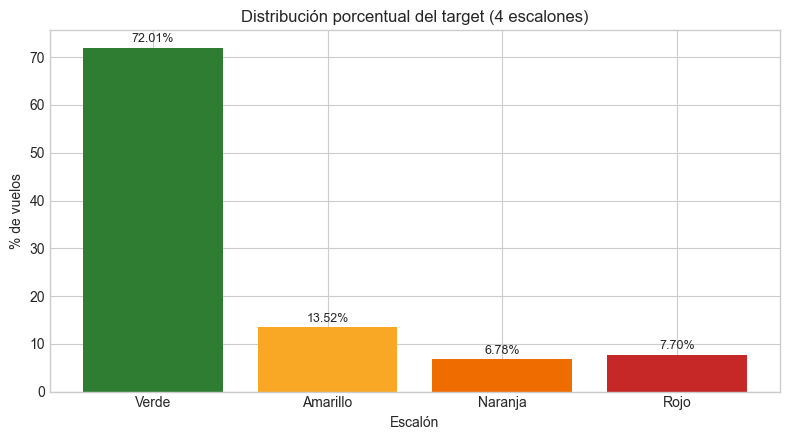

In [14]:
# 1) Distribución del target en 4 escalones
order = ['Verde', 'Amarillo', 'Naranja', 'Rojo']
plot_target = target_dist.reindex(order).reset_index().rename(columns={'index': 'TARGET_4C'})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(plot_target['TARGET_4C'], plot_target['pct'], color=['#2e7d32', '#f9a825', '#ef6c00', '#c62828'])
ax.set_title('Distribución porcentual del target (4 escalones)')
ax.set_xlabel('Escalón')
ax.set_ylabel('% de vuelos')
for i, v in enumerate(plot_target['pct']):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

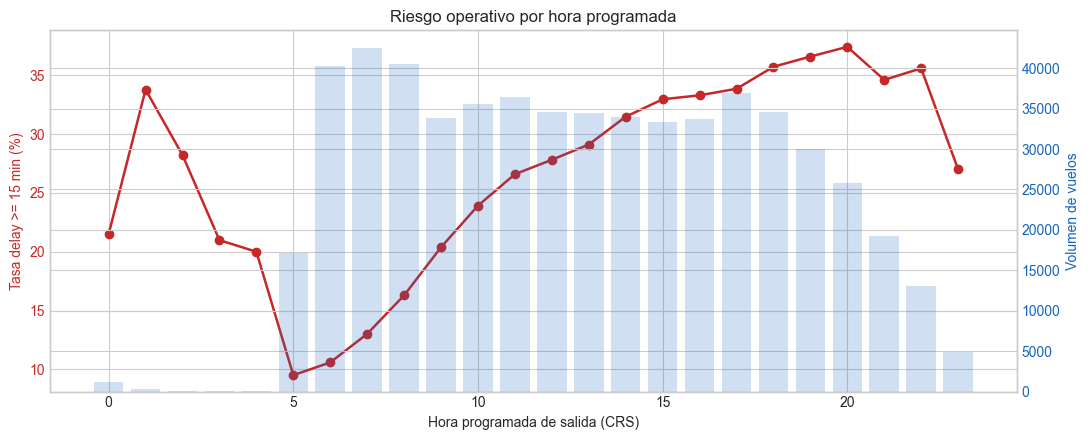

In [15]:
# 2) Riesgo por hora programada de salida (delay >= 15)
by_hour_plot = by_hour.reset_index().dropna(subset=['HOUR_DEP']).sort_values('HOUR_DEP')

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(by_hour_plot['HOUR_DEP'], by_hour_plot['delay_ge15_rate'] * 100, color='#c62828', marker='o', linewidth=1.8)
ax1.set_xlabel('Hora programada de salida (CRS)')
ax1.set_ylabel('Tasa delay >= 15 min (%)', color='#c62828')
ax1.tick_params(axis='y', labelcolor='#c62828')
ax1.set_title('Riesgo operativo por hora programada')

ax2 = ax1.twinx()
ax2.bar(by_hour_plot['HOUR_DEP'], by_hour_plot['flights'], alpha=0.20, color='#1565c0')
ax2.set_ylabel('Volumen de vuelos', color='#1565c0')
ax2.tick_params(axis='y', labelcolor='#1565c0')

plt.tight_layout()
plt.show()

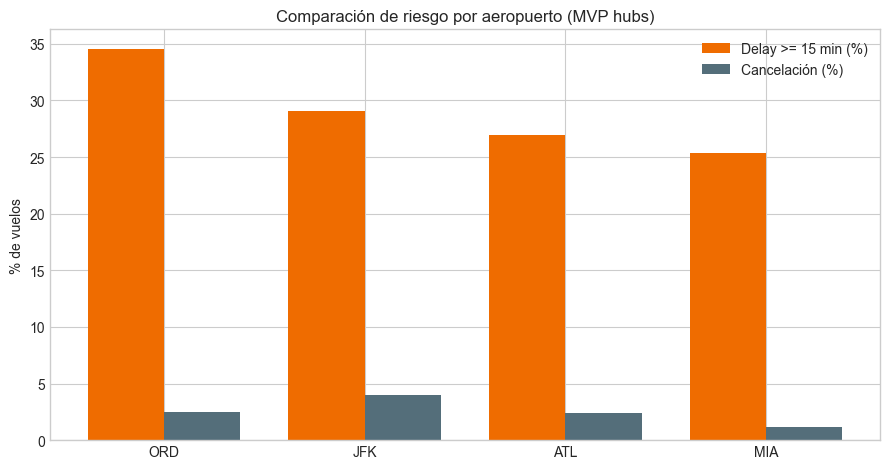

In [16]:
# 3) Comparación de hubs: tasa de delay >= 15 y cancelación
hub_plot = hub_summary.reset_index().sort_values('delay_ge15_rate', ascending=False)

x = np.arange(len(hub_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width / 2, hub_plot['delay_ge15_rate'] * 100, width=width, label='Delay >= 15 min (%)', color='#ef6c00')
ax.bar(x + width / 2, hub_plot['cancel_rate'] * 100, width=width, label='Cancelación (%)', color='#546e7a')
ax.set_xticks(x)
ax.set_xticklabels(hub_plot['ORIGIN'])
ax.set_ylabel('% de vuelos')
ax.set_title('Comparación de riesgo por aeropuerto (MVP hubs)')
ax.legend()
plt.tight_layout()
plt.show()

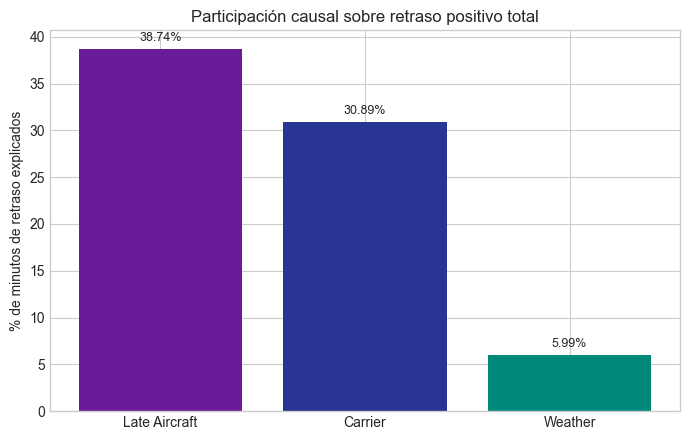

In [17]:
# 4) Participación causal de minutos de retraso positivos
cause_series = explained_pct[['LATE_AIRCRAFT_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY']]
cause_labels = ['Late Aircraft', 'Carrier', 'Weather']

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(cause_labels, cause_series.values, color=['#6a1b9a', '#283593', '#00897b'])
ax.set_title('Participación causal sobre retraso positivo total')
ax.set_ylabel('% de minutos de retraso explicados')
for i, v in enumerate(cause_series.values):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Hipótesis iniciales para priorizar variables

1. La hora programada de salida es un driver fuerte de riesgo, con acumulación de demoras hacia la tarde-noche por efecto cascada operativo.
2. El arrastre logístico (Late Aircraft y features por Tail_Num) debería aportar señal incremental relevante frente a variables estáticas de ruta.
3. ORD y JFK requieren features más sensibles a clima invernal y congestión; MIA puede beneficiarse más de variables de demanda/turnaround que de nieve/icing.
4. La cancelación y el retraso severo comparten factores, pero no son idénticos; conviene mantener target multiclase en vez de binario simple.
5. En entrenamiento multianual, las variables agregadas temporales (lookbacks de 7/30/90 días por aeropuerto/carrier/ruta) podrían estabilizar el modelo y mejorar calibración.

### Variables importantes para el primer baseline (sin leakage)

- Calendar: mes, día semana, franja horaria, feriado.
- Scheduled ops: CRS_DEP_TIME_MIN, CRS_ARR_TIME_MIN, CRS_ELAPSED_TIME, DISTANCE.
- Network: ORIGIN, DEST, carrier, ruta O-D.
- Rolling stats (pasado): tasa delay >= 15, cancelación, percentiles de demora por ORIGIN/carrier/ruta.
- Cascada: turnaround previo y demora histórica reciente por Tail_Num (solo eventos anteriores al vuelo objetivo).
- Clima: variables METAR/SPECI y forecast cercano a hora de salida programada.

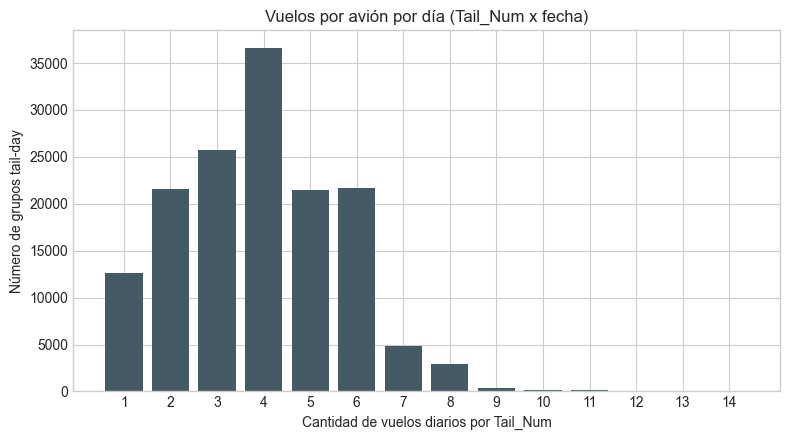

Promedio de vuelos por avión por día: 3.922
Mediana: 4.0
% de tail-day con al menos 2 vuelos: 91.46


In [18]:
# 5) Señal de cascada: actividad por Tail_Num y viabilidad de secuencias
per_tail_day = df.loc[df['TAIL_NUM'].notna()].groupby(['TAIL_NUM', df.loc[df['TAIL_NUM'].notna(), 'FL_DATE'].dt.date]).size()

fig, ax = plt.subplots(figsize=(8, 4.5))
counts = per_tail_day.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color='#455a64')
ax.set_title('Vuelos por avión por día (Tail_Num x fecha)')
ax.set_xlabel('Cantidad de vuelos diarios por Tail_Num')
ax.set_ylabel('Número de grupos tail-day')
plt.tight_layout()
plt.show()

print('Promedio de vuelos por avión por día:', round(per_tail_day.mean(), 3))
print('Mediana:', round(per_tail_day.median(), 3))
print('% de tail-day con al menos 2 vuelos:', round((per_tail_day >= 2).mean() * 100, 2))

## 11. Proporción de razones de retraso por hubs extendidos

Además de ATL, ORD, JFK y MIA, sumamos LAX, DFW, DEN y CLT para contrastar perfiles operativos de hubs de distinta geografía y clima.

En esta sección medimos, para vuelos con retraso positivo, qué proporción de minutos se explica por:
- `LATE_AIRCRAFT_DELAY`
- `CARRIER_DELAY`
- `WEATHER_DELAY`

In [19]:
extended_hubs = ['ATL', 'ORD', 'JFK', 'MIA', 'LAX', 'DFW', 'DEN', 'CLT']
extended_df = df[df['ORIGIN'].isin(extended_hubs)].copy()

rows = []
for hub in extended_hubs:
    sub = extended_df[extended_df['ORIGIN'] == hub]
    pos = sub.loc[sub['DEP_DELAY'] > 0, ['DEP_DELAY', 'LATE_AIRCRAFT_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY']].fillna(0)
    total_pos = pos['DEP_DELAY'].sum()

    if total_pos == 0:
        late_pct = np.nan
        carrier_pct = np.nan
        weather_pct = np.nan
    else:
        late_pct = pos['LATE_AIRCRAFT_DELAY'].sum() / total_pos * 100
        carrier_pct = pos['CARRIER_DELAY'].sum() / total_pos * 100
        weather_pct = pos['WEATHER_DELAY'].sum() / total_pos * 100

    rows.append({
        'ORIGIN': hub,
        'flights': len(sub),
        'delay_ge15_pct': (sub['DEP_DELAY'] >= 15).mean() * 100,
        'cancel_pct': sub['CANCELLED'].mean() * 100,
        'late_aircraft_pct': late_pct,
        'carrier_pct': carrier_pct,
        'weather_pct': weather_pct,
    })

hub_reason_mix = pd.DataFrame(rows).sort_values('delay_ge15_pct', ascending=False)
print('Resumen hubs extendidos:')
display(hub_reason_mix.round(2))

Resumen hubs extendidos:


,ORIGIN,flights,delay_ge15_pct,cancel_pct,late_aircraft_pct,carrier_pct,weather_pct
1,ORD,27790,34.54,2.53,42.38,24.84,14.59
5,DFW,25770,30.34,0.62,43.01,32.90,2.36
2,JFK,8856,29.04,4.02,38.28,30.36,7.40
7,CLT,14975,27.52,0.82,47.18,26.47,3.08
6,DEN,26026,27.51,0.64,38.12,29.24,4.20
0,ATL,25764,26.99,2.38,29.66,39.01,7.83
3,MIA,10099,25.33,1.15,37.63,33.79,1.85
4,LAX,16050,23.85,0.88,33.48,35.50,2.72


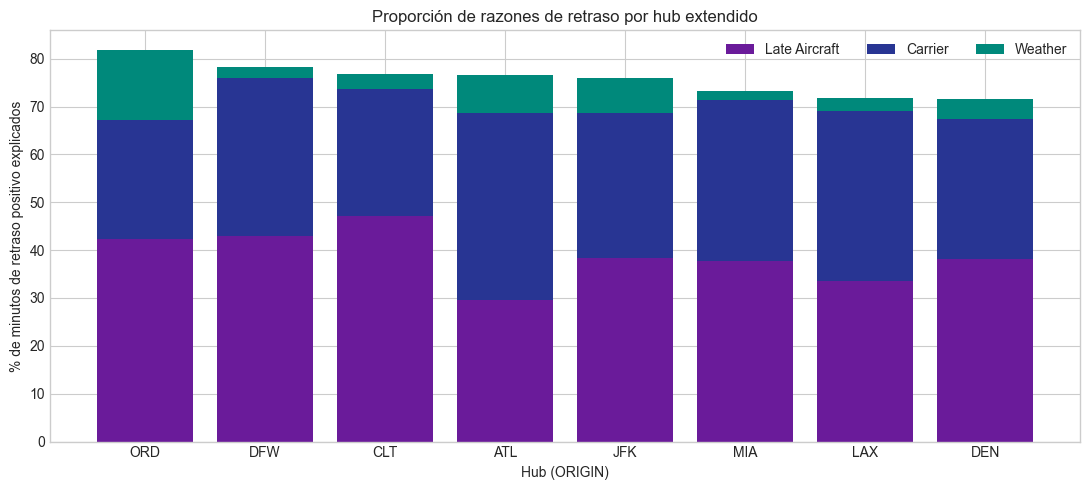

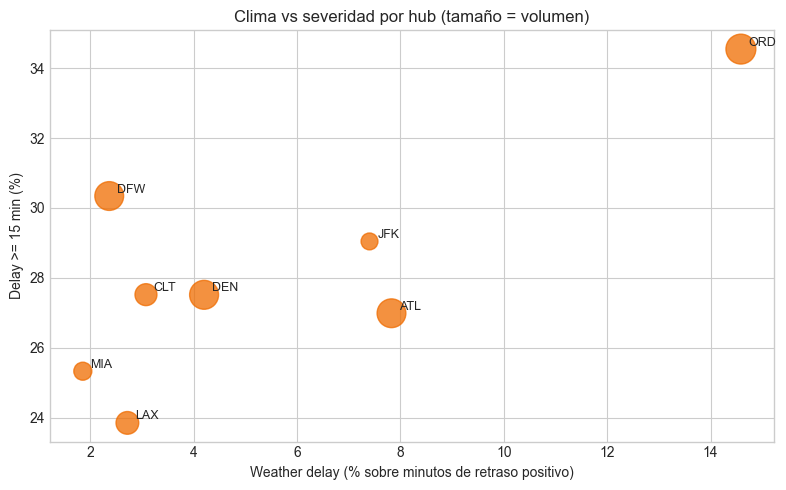

In [20]:
# Gráfico apilado: mezcla de causas sobre minutos de retraso positivos por hub
plot_mix = hub_reason_mix.set_index('ORIGIN')[['late_aircraft_pct', 'carrier_pct', 'weather_pct']].fillna(0)
plot_mix = plot_mix.loc[plot_mix.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(plot_mix.index, plot_mix['late_aircraft_pct'], label='Late Aircraft', color='#6a1b9a')
ax.bar(plot_mix.index, plot_mix['carrier_pct'], bottom=plot_mix['late_aircraft_pct'], label='Carrier', color='#283593')
ax.bar(
    plot_mix.index,
    plot_mix['weather_pct'],
    bottom=plot_mix['late_aircraft_pct'] + plot_mix['carrier_pct'],
    label='Weather',
    color='#00897b',
)

ax.set_title('Proporción de razones de retraso por hub extendido')
ax.set_ylabel('% de minutos de retraso positivo explicados')
ax.set_xlabel('Hub (ORIGIN)')
ax.legend(ncol=3, loc='upper right')
plt.tight_layout()
plt.show()

# Gráfico adicional: relación entre clima y severidad operativa
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    hub_reason_mix['weather_pct'],
    hub_reason_mix['delay_ge15_pct'],
    s=np.clip(hub_reason_mix['flights'] / 60, 30, 500),
    c='#ef6c00',
    alpha=0.75,
)
for _, r in hub_reason_mix.iterrows():
    ax.text(r['weather_pct'] + 0.15, r['delay_ge15_pct'] + 0.1, r['ORIGIN'], fontsize=9)
ax.set_xlabel('Weather delay (% sobre minutos de retraso positivo)')
ax.set_ylabel('Delay >= 15 min (%)')
ax.set_title('Clima vs severidad por hub (tamaño = volumen)')
plt.tight_layout()
plt.show()

### Lectura rápida sugerida

- Si un hub muestra `weather_pct` alto y también `delay_ge15_pct` alto, el módulo climático probablemente tenga mayor impacto allí.
- Si domina `late_aircraft_pct`, conviene priorizar features de cadena logística (tail tracking, turnaround y rolling delays).
- Si `carrier_pct` es alto y estable, agregar agregados históricos por carrier/ruta suele capturar buena parte de la variabilidad operativa.

## 12. Ranking automático de hubs: climate-sensitive vs network-sensitive

Construimos dos scores heurísticos usando los resultados de la sección anterior:

- `climate_score`: combina peso de clima en los minutos de retraso y severidad del hub.
- `network_score`: combina peso de `late_aircraft + carrier` y severidad del hub.

Esto no reemplaza un modelo formal, pero sirve para priorizar ingeniería de features por aeropuerto en el próximo sprint.

In [21]:
ranking = hub_reason_mix.copy()
ranking['network_pct'] = ranking['late_aircraft_pct'] + ranking['carrier_pct']
ranking['climate_ratio'] = ranking['weather_pct'] / ranking['network_pct']

# Scores ponderados por severidad (delay>=15). Dejan los valores en una escala interpretable.
ranking['climate_score'] = ranking['weather_pct'] * ranking['delay_ge15_pct'] / 100
ranking['network_score'] = ranking['network_pct'] * ranking['delay_ge15_pct'] / 100

ranking['perfil'] = np.where(
    ranking['climate_ratio'] >= 0.18,
    'Climate-sensitive',
    np.where(ranking['climate_ratio'] <= 0.08, 'Network-sensitive', 'Mixto')
)

ranking_view = ranking[
    ['ORIGIN', 'flights', 'delay_ge15_pct', 'weather_pct', 'network_pct', 'climate_ratio', 'climate_score', 'network_score', 'perfil']
].sort_values(['climate_score', 'network_score'], ascending=False)

print('Ranking automático de hubs por sensibilidad operativa:')
display(ranking_view.round(3))

Ranking automático de hubs por sensibilidad operativa:


,ORIGIN,flights,delay_ge15_pct,weather_pct,network_pct,climate_ratio,climate_score,network_score,perfil
1,ORD,27790,34.545,14.587,67.221,0.217,5.039,23.221,Climate-sensitive
2,JFK,8856,29.042,7.401,68.640,0.108,2.149,19.935,Mixto
0,ATL,25764,26.987,7.826,68.671,0.114,2.112,18.532,Mixto
6,DEN,26026,27.515,4.200,67.360,0.062,1.156,18.534,Network-sensitive
7,CLT,14975,27.519,3.076,73.650,0.042,0.846,20.268,Network-sensitive
5,DFW,25770,30.341,2.365,75.918,0.031,0.718,23.035,Network-sensitive
4,LAX,16050,23.850,2.716,68.976,0.039,0.648,16.451,Network-sensitive
3,MIA,10099,25.329,1.854,71.422,0.026,0.470,18.091,Network-sensitive


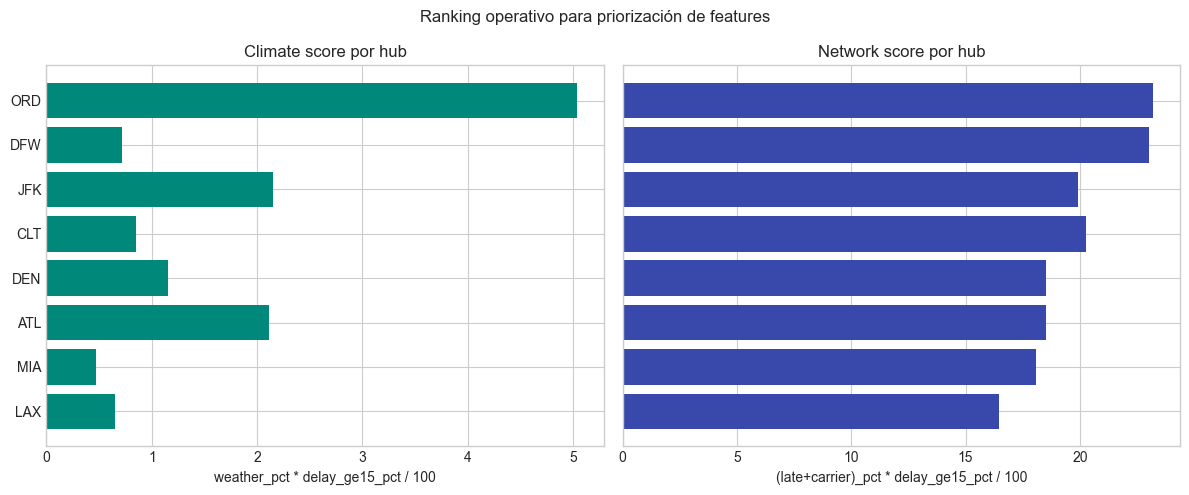

Clusters sugeridos:
- Climate-sensitive: ORD
- Mixto: JFK, ATL
- Network-sensitive: DEN, CLT, DFW, LAX, MIA


In [22]:
plot_rank = ranking_view.sort_values('delay_ge15_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].barh(plot_rank['ORIGIN'], plot_rank['climate_score'], color='#00897b')
axes[0].set_title('Climate score por hub')
axes[0].set_xlabel('weather_pct * delay_ge15_pct / 100')

axes[1].barh(plot_rank['ORIGIN'], plot_rank['network_score'], color='#3949ab')
axes[1].set_title('Network score por hub')
axes[1].set_xlabel('(late+carrier)_pct * delay_ge15_pct / 100')

plt.suptitle('Ranking operativo para priorización de features')
plt.tight_layout()
plt.show()

print('Clusters sugeridos:')
for p in ['Climate-sensitive', 'Mixto', 'Network-sensitive']:
    hubs_p = ranking_view.loc[ranking_view['perfil'] == p, 'ORIGIN'].tolist()
    if hubs_p:
        print(f'- {p}: {", ".join(hubs_p)}')

## 13. Foco ATL: vuelos del hub, delays y extensión meteorológica (IEM)

En esta sección:
- Filtramos todos los vuelos con ORIGIN=ATL o DEST=ATL.
- Definimos el aeropuerto par (`PAR_AIRPORT`) para cada vuelo.
- Calculamos métricas de delay específicas del hub ATL.
- Extendemos la tabla con clima ATL (IEM) recortado a diciembre 2025.

In [3]:
atl_flights = df.loc[df['ORIGIN'].eq('ATL') | df['DEST'].eq('ATL')].copy()
atl_flights['FLOW_ATL'] = np.where(atl_flights['ORIGIN'].eq('ATL'), 'DEP_FROM_ATL', 'ARR_TO_ATL')
atl_flights['PAR_AIRPORT'] = np.where(atl_flights['ORIGIN'].eq('ATL'), atl_flights['DEST'], atl_flights['ORIGIN'])

atl_flights['DEP_DELAY_ATL'] = np.where(atl_flights['FLOW_ATL'].eq('DEP_FROM_ATL'), atl_flights['DEP_DELAY'], np.nan)
atl_flights['ARR_DELAY_ATL'] = np.where(atl_flights['FLOW_ATL'].eq('ARR_TO_ATL'), atl_flights['ARR_DELAY'], np.nan)
atl_flights['DELAY_ATL_MIN'] = np.where(atl_flights['FLOW_ATL'].eq('DEP_FROM_ATL'), atl_flights['DEP_DELAY'], atl_flights['ARR_DELAY'])
atl_flights['DELAY_ATL_GE15'] = atl_flights['DELAY_ATL_MIN'] >= 15

print('Total vuelos del mes:', len(df))
print('Vuelos con origen o destino ATL:', len(atl_flights))
print('Participación de ATL sobre total:', round(len(atl_flights) / len(df) * 100, 2), '%')

atl_delay_summary = pd.DataFrame([
    {
        'segmento': 'Salidas desde ATL',
        'vuelos': int((atl_flights['FLOW_ATL'] == 'DEP_FROM_ATL').sum()),
        'delay_promedio_min': atl_flights.loc[atl_flights['FLOW_ATL'] == 'DEP_FROM_ATL', 'DEP_DELAY'].mean(),
        'delay_mediana_min': atl_flights.loc[atl_flights['FLOW_ATL'] == 'DEP_FROM_ATL', 'DEP_DELAY'].median(),
        'tasa_delay_ge15_pct': atl_flights.loc[atl_flights['FLOW_ATL'] == 'DEP_FROM_ATL', 'DEP_DELAY'].ge(15).mean() * 100,
        'cancel_rate_pct': atl_flights.loc[atl_flights['FLOW_ATL'] == 'DEP_FROM_ATL', 'CANCELLED'].mean() * 100,
    },
    {
        'segmento': 'Llegadas a ATL',
        'vuelos': int((atl_flights['FLOW_ATL'] == 'ARR_TO_ATL').sum()),
        'delay_promedio_min': atl_flights.loc[atl_flights['FLOW_ATL'] == 'ARR_TO_ATL', 'ARR_DELAY'].mean(),
        'delay_mediana_min': atl_flights.loc[atl_flights['FLOW_ATL'] == 'ARR_TO_ATL', 'ARR_DELAY'].median(),
        'tasa_delay_ge15_pct': atl_flights.loc[atl_flights['FLOW_ATL'] == 'ARR_TO_ATL', 'ARR_DELAY'].ge(15).mean() * 100,
        'cancel_rate_pct': atl_flights.loc[atl_flights['FLOW_ATL'] == 'ARR_TO_ATL', 'CANCELLED'].mean() * 100,
    },
])

print('\nResumen de delays del hub ATL:')
display(atl_delay_summary.round(2))

par_rank = atl_flights.groupby('PAR_AIRPORT').agg(
    vuelos=('FL_DATE', 'size'),
    delay_hub_promedio_min=('DELAY_ATL_MIN', 'mean'),
    delay_hub_ge15_pct=('DELAY_ATL_GE15', 'mean'),
).sort_values('vuelos', ascending=False)
par_rank['delay_hub_ge15_pct'] = (par_rank['delay_hub_ge15_pct'] * 100).round(2)

print('\nTop pares de ATL por volumen (con delay sobre el lado ATL):')
display(par_rank.head(20))

Total vuelos del mes: 582304
Vuelos con origen o destino ATL: 51545
Participación de ATL sobre total: 8.85 %

Resumen de delays del hub ATL:


,segmento,vuelos,delay_promedio_min,delay_mediana_min,tasa_delay_ge15_pct,cancel_rate_pct
0,Salidas desde ATL,25764,17.79,0.0,26.99,2.38
1,Llegadas a ATL,25781,8.00,-9.0,20.95,2.57



Top pares de ATL por volumen (con delay sobre el lado ATL):


,vuelos,delay_hub_promedio_min,delay_hub_ge15_pct
PAR_AIRPORT,,,
LGA,1505,24.497884,31.83
MCO,1440,17.837341,29.38
FLL,1373,19.505979,32.63
MIA,1171,13.530594,26.30
DFW,1148,14.000890,25.44
DCA,1087,15.624642,29.07
EWR,1046,26.934459,32.60
TPA,1005,13.876268,27.86
ORD,978,23.857445,31.90


### Estrategia para consumir meteorología del aeropuerto PAR

Definición operativa de PAR por vuelo:
- Si `ORIGIN == ATL`, entonces `PAR_AIRPORT = DEST`.
- Si `DEST == ATL`, entonces `PAR_AIRPORT = ORIGIN`.

Estrategia recomendada:
1. Construir un catálogo de estaciones IEM por aeropuerto (`airport -> station`) y mantenerlo versionado.
2. Generar `event_time_par` por vuelo en zona horaria UTC/local normalizada:
   - Salida desde ATL: hora relevante en PAR es la llegada programada al PAR.
   - Llegada a ATL: hora relevante en PAR es la salida programada desde PAR.
3. Extraer series meteorológicas por estación PAR con ventana temporal mensual y granularidad horaria.
4. Hacer `merge_asof` por vuelo con tolerancia (ej. 60–90 min) y guardar `weather_gap_min` para control de calidad.
5. Definir features robustas por PAR (precipitación, visibilidad baja, ráfagas/viento, temperatura, humedad) y flags de severidad.

Con esta base, la tabla queda preparada para sumar clima del par además del clima local en ATL.

In [4]:
IEM_PATH = '/Users/mateopappalardo/Downloads/tesis_local/IEM_DATA_ATL_2025.csv'
iem = pd.read_csv(IEM_PATH, low_memory=False)
iem.columns = [c.strip().lower() for c in iem.columns]
iem['valid'] = pd.to_datetime(iem['valid'], errors='coerce')

# El IEM viene para todo 2025; recortamos a diciembre para alinear con los vuelos del mes.
iem_dec = iem.loc[iem['valid'].dt.month == 12].copy().sort_values('valid')

wx_cols = ['tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'p01m', 'vsby']
for col in wx_cols:
    if col in iem_dec.columns:
        iem_dec[col] = pd.to_numeric(iem_dec[col].replace('M', np.nan), errors='coerce')

iem_dec['wx_precip_flag'] = iem_dec['p01m'].fillna(0) > 0
iem_dec['wx_low_vis_flag'] = iem_dec['vsby'] < 3
iem_dec['wx_strong_wind_flag'] = (iem_dec['sknt'] >= 20) | (iem_dec['gust'] >= 30)


def hhmm_to_timedelta(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors='coerce')
    hours = np.floor(values / 100)
    minutes = values % 100
    invalid = (values < 0) | (hours > 23) | (minutes >= 60)
    out = pd.Series(pd.to_timedelta(hours * 60 + minutes, unit='m'), index=series.index)
    out[invalid] = pd.NaT
    return out


dep_td = hhmm_to_timedelta(atl_flights['CRS_DEP_TIME'])
arr_td = hhmm_to_timedelta(atl_flights['CRS_ARR_TIME'])

arr_rollover = arr_td.notna() & dep_td.notna() & (arr_td < dep_td)
arr_td_adj = arr_td + pd.to_timedelta(arr_rollover.astype(int), unit='D')

atl_flights['SCHED_DEP_DT'] = atl_flights['FL_DATE'] + dep_td
atl_flights['SCHED_ARR_DT'] = atl_flights['FL_DATE'] + arr_td_adj
atl_flights['EVENT_TIME_ATL'] = np.where(
    atl_flights['FLOW_ATL'].eq('DEP_FROM_ATL'),
    atl_flights['SCHED_DEP_DT'],
    atl_flights['SCHED_ARR_DT'],
)
atl_flights['EVENT_TIME_ATL'] = pd.to_datetime(atl_flights['EVENT_TIME_ATL'], errors='coerce')

atl_enriched = pd.merge_asof(
    atl_flights.sort_values('EVENT_TIME_ATL'),
    iem_dec.sort_values('valid')[['valid', 'tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'p01m', 'vsby', 'wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag']],
    left_on='EVENT_TIME_ATL',
    right_on='valid',
    direction='nearest',
    tolerance=pd.Timedelta('90min'),
)

atl_enriched['WX_MATCH_GAP_MIN'] = (atl_enriched['EVENT_TIME_ATL'] - atl_enriched['valid']).abs().dt.total_seconds() / 60

match_rate = atl_enriched['valid'].notna().mean() * 100
print('Observaciones meteo diciembre ATL (IEM):', len(iem_dec))
print('Vuelos ATL enriquecidos con clima:', len(atl_enriched))
print('Tasa de match meteo-vuelo:', round(match_rate, 2), '%')
print('Gap mediano de emparejamiento (min):', round(atl_enriched['WX_MATCH_GAP_MIN'].median(), 2))

atl_weather_view = atl_enriched[
    [
        'FL_DATE', 'ORIGIN', 'DEST', 'PAR_AIRPORT', 'FLOW_ATL', 'OP_CARRIER', 'OP_CARRIER_FL_NUM',
        'DEP_DELAY', 'ARR_DELAY', 'CANCELLED',
        'EVENT_TIME_ATL', 'valid', 'WX_MATCH_GAP_MIN',
        'tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'p01m', 'vsby',
        'wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag',
    ]
].copy()

OUT_PATH = '/Users/mateopappalardo/Downloads/tesis_local/ATL_DEC_2025_BTS_IEM_EXT.csv'
atl_weather_view.to_csv(OUT_PATH, index=False)

print('\nMuestra de la tabla extendida ATL + meteo:')
display(atl_weather_view.head(10))
print('CSV exportado en:', OUT_PATH)

Observaciones meteo diciembre ATL (IEM): 884
Vuelos ATL enriquecidos con clima: 51545
Tasa de match meteo-vuelo: 97.36 %
Gap mediano de emparejamiento (min): 12.0

Muestra de la tabla extendida ATL + meteo:


,FL_DATE,ORIGIN,DEST,PAR_AIRPORT,FLOW_ATL,OP_CARRIER,OP_CARRIER_FL_NUM,DEP_DELAY,ARR_DELAY,CANCELLED,EVENT_TIME_ATL,valid,WX_MATCH_GAP_MIN,tmpc,dwpc,relh,drct,sknt,gust,p01m,vsby,wx_precip_flag,wx_low_vis_flag,wx_strong_wind_flag
0,2025-12-01,ATL,IAH,IAH,DEP_FROM_ATL,UA,1807,-7.0,-9.0,0.0,2025-12-01 05:14:00,2025-12-01 04:52:00,22.0,7.22,5.00,85.77,330.0,8.0,NaN,0.0,10.0,False,False,False
1,2025-12-01,ATL,PHX,PHX,DEP_FROM_ATL,AA,2902,-4.0,-8.0,0.0,2025-12-01 05:15:00,2025-12-01 04:52:00,23.0,7.22,5.00,85.77,330.0,8.0,NaN,0.0,10.0,False,False,False
2,2025-12-01,ATL,FLL,FLL,DEP_FROM_ATL,NK,2250,157.0,147.0,0.0,2025-12-01 05:20:00,2025-12-01 04:52:00,28.0,7.22,5.00,85.77,330.0,8.0,NaN,0.0,10.0,False,False,False
3,2025-12-01,ATL,DFW,DFW,DEP_FROM_ATL,AA,2770,-8.0,-16.0,0.0,2025-12-01 05:35:00,2025-12-01 05:52:00,17.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
4,2025-12-01,ATL,MCO,MCO,DEP_FROM_ATL,NK,2252,4.0,-8.0,0.0,2025-12-01 05:45:00,2025-12-01 05:52:00,7.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
5,2025-12-01,DEN,ATL,DEN,ARR_TO_ATL,DL,302,6.0,-15.0,0.0,2025-12-01 05:46:00,2025-12-01 05:52:00,6.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
6,2025-12-01,ATL,DCA,DCA,DEP_FROM_ATL,OH,5147,-6.0,-20.0,0.0,2025-12-01 06:00:00,2025-12-01 05:52:00,8.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
7,2025-12-01,ATL,DTW,DTW,DEP_FROM_ATL,DL,651,3.0,-8.0,0.0,2025-12-01 06:00:00,2025-12-01 05:52:00,8.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
8,2025-12-01,ATL,PHL,PHL,DEP_FROM_ATL,AA,3070,1.0,-12.0,0.0,2025-12-01 06:00:00,2025-12-01 05:52:00,8.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False
9,2025-12-01,ATL,DTW,DTW,DEP_FROM_ATL,F9,1264,54.0,65.0,0.0,2025-12-01 06:00:00,2025-12-01 05:52:00,8.0,6.67,3.89,82.43,320.0,13.0,17.0,0.0,10.0,False,False,False


CSV exportado en: /Users/mateopappalardo/Downloads/tesis_local/ATL_DEC_2025_BTS_IEM_EXT.csv


## 14. Mini EDA de la extensión ATL + IEM

Chequeamos rápidamente calidad del dataset extendido:
- cobertura del match temporal vuelo-meteo,
- nulos y duplicados,
- distribución de delay sobre el lado ATL,
- señal de severidad bajo banderas meteorológicas.

Objetivo: validar si la tabla ya está usable para modelado y feature engineering.

In [5]:
mini = atl_weather_view.copy()

# Reforzamos tipos para evitar sorpresas si se vuelve a cargar desde CSV.
mini['EVENT_TIME_ATL'] = pd.to_datetime(mini['EVENT_TIME_ATL'], errors='coerce')
mini['valid'] = pd.to_datetime(mini['valid'], errors='coerce')
for col in ['DEP_DELAY', 'ARR_DELAY', 'WX_MATCH_GAP_MIN', 'tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'p01m', 'vsby']:
    if col in mini.columns:
        mini[col] = pd.to_numeric(mini[col], errors='coerce')

mini['DELAY_ATL_MIN'] = np.where(mini['FLOW_ATL'].eq('DEP_FROM_ATL'), mini['DEP_DELAY'], mini['ARR_DELAY'])
mini['DELAY_ATL_GE15'] = mini['DELAY_ATL_MIN'] >= 15
mini['MATCHED_WX'] = mini['valid'].notna()

print('Shape dataset extendido:', mini.shape)
print('Duplicados exactos:', int(mini.duplicated().sum()))
print('Cobertura meteo (% filas con match):', round(mini['MATCHED_WX'].mean() * 100, 2))
print('Gap mediano de match (min):', round(mini['WX_MATCH_GAP_MIN'].median(), 2))
print('Gap p95 de match (min):', round(mini['WX_MATCH_GAP_MIN'].quantile(0.95), 2))

null_check = mini[['valid', 'WX_MATCH_GAP_MIN', 'tmpc', 'sknt', 'gust', 'p01m', 'vsby']].isna().mean().mul(100).round(2).to_frame('null_pct')
print('\nNulos (%) en columnas meteorológicas clave:')
display(null_check)

delay_profile = mini['DELAY_ATL_MIN'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('delay_atl_min')
print('\nPerfil de delay lado ATL (min):')
display(delay_profile)

flag_impact = mini.groupby(['wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag']).agg(
    vuelos=('DELAY_ATL_MIN', 'size'),
    delay_promedio_min=('DELAY_ATL_MIN', 'mean'),
    delay_mediana_min=('DELAY_ATL_MIN', 'median'),
    delay_ge15_pct=('DELAY_ATL_GE15', 'mean'),
).reset_index().sort_values('vuelos', ascending=False)
flag_impact['delay_ge15_pct'] = (flag_impact['delay_ge15_pct'] * 100).round(2)

print('\nImpacto de banderas meteo sobre delay ATL:')
display(flag_impact.head(10).round(2))

pair_quality = mini.groupby('PAR_AIRPORT').agg(
    vuelos=('DELAY_ATL_MIN', 'size'),
    delay_promedio_min=('DELAY_ATL_MIN', 'mean'),
    delay_ge15_pct=('DELAY_ATL_GE15', 'mean'),
    wx_match_pct=('MATCHED_WX', 'mean'),
).sort_values('vuelos', ascending=False)
pair_quality['delay_ge15_pct'] = (pair_quality['delay_ge15_pct'] * 100).round(2)
pair_quality['wx_match_pct'] = (pair_quality['wx_match_pct'] * 100).round(2)

print('\nTop 15 pares ATL (volumen + calidad de match):')
display(pair_quality.head(15))

Shape dataset extendido: (51545, 27)
Duplicados exactos: 0
Cobertura meteo (% filas con match): 97.36
Gap mediano de match (min): 12.0
Gap p95 de match (min): 28.0

Nulos (%) en columnas meteorológicas clave:


,null_pct
valid,2.64
WX_MATCH_GAP_MIN,2.64
tmpc,2.64
sknt,2.64
gust,83.41
p01m,8.87
vsby,2.64



Perfil de delay lado ATL (min):


,delay_atl_min
count,50225.000000
mean,12.907437
std,61.909037
min,-63.000000
10%,-22.000000
25%,-10.000000
50%,-2.000000
75%,14.000000
90%,54.000000
95%,101.000000



Impacto de banderas meteo sobre delay ATL:


,wx_precip_flag,wx_low_vis_flag,wx_strong_wind_flag,vuelos,delay_promedio_min,delay_mediana_min,delay_ge15_pct
0,False,False,False,43813,10.31,-3.0,22.59
2,False,True,False,3475,48.07,7.0,40.35
1,False,False,True,1047,17.32,0.0,30.85
5,True,True,False,901,18.66,0.0,25.42
3,True,False,False,860,11.81,-1.0,25.70
6,True,True,True,68,12.34,-2.0,19.12
4,True,False,True,21,6.90,-6.5,14.29



Top 15 pares ATL (volumen + calidad de match):


,vuelos,delay_promedio_min,delay_ge15_pct,wx_match_pct
PAR_AIRPORT,,,,
LGA,1505,24.497884,31.83,97.74
MCO,1440,17.837341,29.38,96.94
FLL,1373,19.505979,32.63,97.01
MIA,1171,13.530594,26.30,96.41
DFW,1148,14.000890,25.44,97.13
DCA,1087,15.624642,29.07,97.61
EWR,1046,26.934459,32.60,97.32
TPA,1005,13.876268,27.86,97.51
ORD,978,23.857445,31.90,97.75


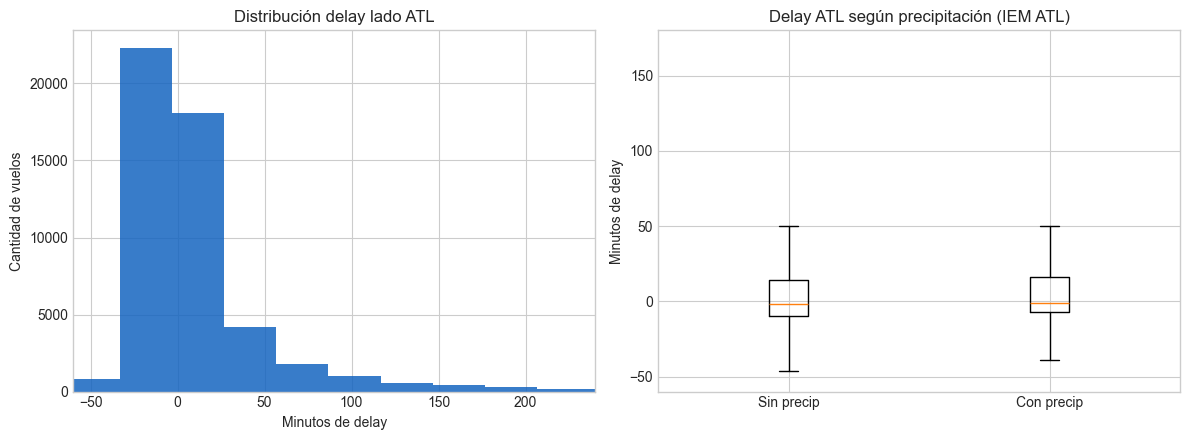

Frecuencia de condiciones meteorológicas severas en ATL (%):
wx_precip_flag         3.63
wx_low_vis_flag        8.39
wx_strong_wind_flag    2.22


In [8]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plot_df = mini.dropna(subset=['DELAY_ATL_MIN']).copy()

flag_cols = ['wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag']
flag_num = plot_df[flag_cols].apply(
    lambda s: s.astype('string').str.lower().map({'true': 1, 'false': 0})
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(plot_df['DELAY_ATL_MIN'], bins=60, color='#1565c0', alpha=0.85)
axes[0].set_title('Distribución delay lado ATL')
axes[0].set_xlabel('Minutos de delay')
axes[0].set_ylabel('Cantidad de vuelos')
axes[0].set_xlim(-60, 240)

box_data = [
    plot_df.loc[flag_num['wx_precip_flag'].eq(0), 'DELAY_ATL_MIN'],
    plot_df.loc[flag_num['wx_precip_flag'].eq(1), 'DELAY_ATL_MIN'],
]
axes[1].boxplot(box_data, tick_labels=['Sin precip', 'Con precip'], showfliers=False)
axes[1].set_title('Delay ATL según precipitación (IEM ATL)')
axes[1].set_ylabel('Minutos de delay')
axes[1].set_ylim(-60, 180)

plt.tight_layout()
plt.show()

severe_mix = flag_num.mean().mul(100).round(2)
print('Frecuencia de condiciones meteorológicas severas en ATL (%):')
print(severe_mix.to_string())

## 15. Correlation matrices para validar hipótesis (ATL + clima)

En este bloque probamos hipótesis operativas con correlaciones sobre la extensión ATL+IEM:
- Si baja la visibilidad, debería subir la severidad del delay.
- Si aumenta viento/ráfagas o precipitación, debería aumentar la probabilidad de delay >= 15.
- Las relaciones pueden ser no lineales, por eso vemos Pearson y Spearman.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Base robusta: usa la tabla en memoria si existe, si no, la carga desde CSV exportado.
try:
    corr_base = atl_weather_view.copy()
except NameError:
    corr_base = pd.read_csv('/Users/mateopappalardo/Downloads/tesis_local/ATL_DEC_2025_BTS_IEM_EXT.csv')

corr_base['EVENT_TIME_ATL'] = pd.to_datetime(corr_base['EVENT_TIME_ATL'], errors='coerce')
corr_base['valid'] = pd.to_datetime(corr_base['valid'], errors='coerce')

for col in ['DEP_DELAY', 'ARR_DELAY', 'WX_MATCH_GAP_MIN', 'tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'p01m', 'vsby']:
    if col in corr_base.columns:
        corr_base[col] = pd.to_numeric(corr_base[col], errors='coerce')

for col in ['wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag']:
    corr_base[col] = corr_base[col].astype('string').str.lower().map({'true': 1, 'false': 0})

corr_base['DELAY_ATL_MIN'] = np.where(corr_base['FLOW_ATL'].eq('DEP_FROM_ATL'), corr_base['DEP_DELAY'], corr_base['ARR_DELAY'])
corr_base['DELAY_ATL_GE15'] = (corr_base['DELAY_ATL_MIN'] >= 15).astype(float)
corr_base['WX_MATCHED'] = corr_base['valid'].notna().astype(float)

# Tomamos solo filas con clima matcheado para no sesgar correlaciones por nulos estructurales.
corr_df = corr_base.loc[corr_base['WX_MATCHED'].eq(1)].copy()

corr_features = [
    'DELAY_ATL_MIN', 'DELAY_ATL_GE15',
    'tmpc', 'dwpc', 'relh', 'drct', 'sknt', 'gust', 'p01m', 'vsby',
    'wx_precip_flag', 'wx_low_vis_flag', 'wx_strong_wind_flag',
    'WX_MATCH_GAP_MIN'
]

corr_data = corr_df[corr_features].copy()

pearson = corr_data.corr(method='pearson', min_periods=200)
spearman = corr_data.corr(method='spearman', min_periods=200)

print('Filas usadas para correlación:', len(corr_data))
print('\nCorrelaciones con DELAY_ATL_MIN (Pearson):')
display(pearson['DELAY_ATL_MIN'].sort_values(ascending=False).to_frame('pearson'))
print('\nCorrelaciones con DELAY_ATL_GE15 (Spearman):')
display(spearman['DELAY_ATL_GE15'].sort_values(ascending=False).to_frame('spearman'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    pearson,
    cmap='RdBu_r',
    center=0,
    vmin=-0.35,
    vmax=0.35,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Correlation matrix Pearson')

sns.heatmap(
    spearman,
    cmap='RdBu_r',
    center=0,
    vmin=-0.35,
    vmax=0.35,
    square=True,
    ax=axes[1]
)
axes[1].set_title('Correlation matrix Spearman')

plt.tight_layout()
plt.show()